# Assignment 2 — The Cost of Being Wrong
**DSA 8401 Applied Machine Learning**

This notebook uses the final dataframe produced by Assignment 1 and keeps `is_fraud` as the target because that is the actual target in the supplied dataset.

Workflow:
1. Load the exact A1 output.
2. Create blocked/purged time-series folds.
3. Compare regularised Logistic Regression, Random Forest, and LightGBM on the same folds.
4. Compare imbalance remedies.
5. Demonstrate why resampling outside folds is invalid.
6. Run a 60-trial Optuna study.
7. Calibrate probabilities.
8. Choose a cost-minimising threshold and compare it with 0.50.
9. Run subgroup fairness checks.
10. Produce global and local SHAP explanations.
11. Save model comparison tables, Optuna DB, predictions, model and calibrator.


In [1]:
# Core imports and business settings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    confusion_matrix, precision_recall_curve
)

from sklearn.calibration import calibration_curve

from lightgbm import LGBMClassifier

from pathlib import Path

PROJECT_ROOT = Path("..")
DATA_DIR  = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR  = PROJECT_ROOT / "figures"
DB_DIR   = PROJECT_ROOT / "db"

RANDOM_STATE = 42
TARGET = "is_fraud"
TIME_COL = "ts"


# Assignment 2 cost assumptions
COST_FN = 10_000  # missed fraud
COST_FP = 800     # legitimate transaction wrongly flagged
THEORETICAL_COST_THRESHOLD = COST_FP / (COST_FP + COST_FN)

print(f"Theoretical cost threshold (if probabilities are calibrated): {THEORETICAL_COST_THRESHOLD:.4f}")


Theoretical cost threshold (if probabilities are calibrated): 0.0741


## 1. Load the exact Assignment 1 output

Run the save cell at the end of the A1 notebook first. The pickle format preserves dataframe dtypes, including the parsed datetime column.


In [2]:
import json

A1_FILE = DATA_DIR / "053837_a1_modelling_table.pkl"

meta_path = MODEL_DIR / "053837_credit_risk_pipeline_meta.json"
artifact = json.loads(meta_path.read_text()) if meta_path.exists() else None

if artifact is not None:
    NUMERICAL_COLS = artifact["numerical_cols"]
    CATEGORY_COLS  = artifact["categorical_cols"]
    TARGET         = artifact["target"]
    GROUP          = artifact["group"]
else:
    raise FileNotFoundError(
        "053837_credit_risk_pipeline_meta.json not found — "
        "run the export cell at the end of A1 notebook first."
    )

df = pd.read_pickle(A1_FILE)

print("Shape:", df.shape)
print("Customers:", f"{df[GROUP].nunique():,}")
print("Fraud cases:", f"{df[TARGET].sum():,}")
print("Fraud prevalence:", f"{df[TARGET].mean():.2%}")
print("Date range:", df[TIME_COL].min(), "to", df[TIME_COL].max())


Shape: (180000, 38)
Customers: 3,991
Fraud cases: 15,134
Fraud prevalence: 8.41%
Date range: 2025-02-06 00:46:00 to 2026-07-31 22:11:42


In [3]:
df.head()

,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,...,payday_dist,log_amt,gps_missing,recency_days,frequency,monetary_out,monetary_in,n_counterparty,cashout_ratio,out_in_ratio
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,...,2,7.192934,1,12.508333,125,158085.0,73259.0,123,0.136000,2.157862
1,TXN0155490,254700013612,NID103658,Rehema Ndlovu,Mombasa,retail,"Jan 29, 2026 01:17 PM",send,289/- Dr,1.77470,...,1,5.669881,0,12.170995,59,60882.0,44395.0,58,0.118644,1.371340
2,TXN0019434,254700005862,nid101584,Mary Mutua,Arusha,retail,"Sep 16, 2025 12:55 AM",receive,"1,571/-",-3.74336,...,12,7.360104,0,1.488889,31,33101.0,26404.0,31,0.129032,1.253588
3,TXN0049426,254700009223,NID102493,Joseph Okoth,Dar es Salaam,retail,07/04/2026 11:21,send,599/- Dr,NaN,...,6,6.396930,1,11.831250,57,55441.0,43814.0,57,0.192982,1.265343
4,TXN0013816,254700014760,nid103963,B. Ssentongo,Mwanza,retail,20/12/2025 11:05,cashout,"(1,307/-)",0.08284,...,8,7.176255,0,61.410417,30,20281.0,26804.0,30,0.066667,0.756613


In [3]:
# Feature set retained from Assignment 1
LEAKAGE_COLS = ["manual_review_score", "settlement_status"]
FEATURE_COLS = NUMERICAL_COLS + CATEGORY_COLS

missing = [c for c in FEATURE_COLS + [TARGET, TIME_COL] if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"
assert not any(c in FEATURE_COLS for c in LEAKAGE_COLS)

data = df.sort_values(TIME_COL).reset_index(drop=True).copy()
X = data[FEATURE_COLS]
y = data[TARGET].astype(int)
groups = data[GROUP]
ts     = data[TIME_COL].copy()

print("Modelling rows:", f"{len(data):,}")
print("Positive rate:", f"{y.mean():.2%}")


Modelling rows: 180,000
Positive rate: 8.41%


### Honesty-check holdout

Before any cross-validation or Optuna tuning touches the data, carve out the most
recent 15% of customers as an untouched test set. This is separate from — and in
addition to — the purged CV folds used for model selection: those folds still do
their job of comparing models and picking hyperparameters honestly *within* the
remaining data, while this holdout answers a different question: how optimistic is
our final reported score, given it was chosen by a 60-trial search? (Optuna's
`study.best_value` is the max of 60 noisy CV scores, and the max of many noisy
estimates is biased upward — the "winner's curse.")

In [4]:

# IMPORTANT:
# - Holdout is selected strictly by TIME, not by customer.
# - A purge gap separates development data from the holdout.
# - Holdout must not be used for CV, Optuna, calibration,
#   threshold selection, SHAP selection, or model selection.


HOLDOUT_FRACTION = 0.15
HOLDOUT_PURGE_DAYS = 7

# Ensure strict chronological ordering
data = data.sort_values(TIME_COL).reset_index(drop=True)

#  Determine the temporal cutoff
split_position = int(len(data) * (1 - HOLDOUT_FRACTION))

holdout_start_time = data.loc[split_position, TIME_COL]

# Purge period immediately before the holdout
dev_end_time = holdout_start_time - pd.Timedelta(
    days=HOLDOUT_PURGE_DAYS
)

print("Holdout starts:", holdout_start_time)
print("Development must end before:", dev_end_time)



# Create masks

# Development: strictly before purge boundary
dev_mask = data[TIME_COL] < dev_end_time

# Holdout: strict recent period
holdout_mask = data[TIME_COL] >= holdout_start_time

# Rows between dev_end_time and holdout_start_time are deliberately
# excluded as the temporal purge gap.
purge_mask = (
    (data[TIME_COL] >= dev_end_time)
    & (data[TIME_COL] < holdout_start_time)
)



# Build development and untouched holdout sets


df_dev = data.loc[dev_mask].copy().reset_index(drop=True)

df_test = data.loc[holdout_mask].copy().reset_index(drop=True)

df_purge = data.loc[purge_mask].copy().reset_index(drop=True)



# Rebuild modelling objects

X = df_dev[FEATURE_COLS].copy()
y = df_dev[TARGET].astype(int).copy()

groups = df_dev[GROUP].copy()
ts = df_dev[TIME_COL].copy()


# Untouched final holdout
X_test = df_test[FEATURE_COLS].copy()
y_test = df_test[TARGET].astype(int).copy()

groups_test = df_test[GROUP].copy()
ts_test = df_test[TIME_COL].copy()


# Sanity checks


assert ts.max() < ts_test.min(), \
    "Temporal leakage: development overlaps the holdout."

assert ts.max() < dev_end_time, \
    "Development data entered the purge period."

assert ts_test.min() >= holdout_start_time, \
    "Holdout begins before the intended cutoff."



# Report split


print("\n" + "=" * 65)
print("OUT-OF-TIME HOLDOUT DESIGN")
print("=" * 65)

print(
    f"Development set: "
    f"{len(X):,} rows | "
    f"{groups.nunique():,} customers"
)

print(
    f"Purged observations: "
    f"{len(df_purge):,}"
)

print(
    f"Untouched holdout: "
    f"{len(X_test):,} rows | "
    f"{groups_test.nunique():,} customers"
)

print(
    f"\nDevelopment period: "
    f"{ts.min()}  -->  {ts.max()}"
)

print(
    f"Purged period:      "
    f"{df_purge[TIME_COL].min() if len(df_purge) else 'None'}"
    f"  -->  "
    f"{df_purge[TIME_COL].max() if len(df_purge) else 'None'}"
)

print(
    f"Holdout period:     "
    f"{ts_test.min()}  -->  {ts_test.max()}"
)

print(
    f"\nDevelopment fraud rate: "
    f"{y.mean():.2%}"
)

print(
    f"Holdout fraud rate:     "
    f"{y_test.mean():.2%}"
)

print(
    f"\nCustomer overlap between dev and holdout: "
    f"{len(set(groups) & set(groups_test)):,}"
)

Holdout starts: 2026-05-11 07:21:00
Development must end before: 2026-05-04 07:21:00

OUT-OF-TIME HOLDOUT DESIGN
Development set: 150,700 rows | 3,987 customers
Purged observations: 2,300
Untouched holdout: 27,000 rows | 3,790 customers

Development period: 2025-02-06 00:46:00  -->  2026-05-04 07:16:17
Purged period:      2026-05-04 07:31:00  -->  2026-05-11 07:18:15
Holdout period:     2026-05-11 07:21:00  -->  2026-07-31 22:11:42

Development fraud rate: 8.40%
Holdout fraud rate:     8.44%

Customer overlap between dev and holdout: 3,786


## 2. Blocked / purged time-series cross-validation

The principal leakage risk is **temporal leakage**: training observations must
never occur after validation observations. Five expanding-window validation
folds are therefore used, with a seven-day purge before each validation
window.

The data are divided chronologically into six contiguous blocks. Block 1 is the initial training history; Blocks 2–6 are five validation windows. For each fold, a 7-day purge is removed immediately before validation. Every model family uses the exact same fold indices.


In [5]:
N_SPLITS = 5
PURGE_DAYS = 7

def make_purged_folds(frame, time_col=TIME_COL, n_splits=N_SPLITS, purge_days=PURGE_DAYS):
    n = len(frame)
    blocks = np.array_split(np.arange(n), n_splits + 1)
    folds = []

    for fold_no in range(n_splits):
        val_idx = blocks[fold_no + 1]
        val_start_time = frame.loc[val_idx[0], time_col]
        purge_cutoff = val_start_time - pd.Timedelta(days=purge_days)
        train_idx = np.where(frame[time_col].values < np.datetime64(purge_cutoff))[0]

        assert len(train_idx) > 0
        assert train_idx.max() < val_idx.min()
        folds.append((train_idx, val_idx))

    return folds

folds = make_purged_folds(df_dev)
fold_summary = []

for fold_no, (train_idx, val_idx) in enumerate(folds, start=1):
    fold_summary.append({
        "Fold": fold_no,
        "Train n": len(train_idx),
        "Validation n": len(val_idx),
        "Train end": df_dev.loc[train_idx[-1], TIME_COL],
        "Validation start": df_dev.loc[val_idx[0], TIME_COL],
        "Validation end": df_dev.loc[val_idx[-1], TIME_COL],
        "Train fraud rate": y.iloc[train_idx].mean(),
        "Validation fraud rate": y.iloc[val_idx].mean(),
    })

fold_summary = pd.DataFrame(fold_summary)
fold_summary


,Fold,Train n,Validation n,Train end,Validation start,Validation end,Train fraud rate,Validation fraud rate
0,1,22726,25117,2025-04-16 04:54:41,2025-04-23 04:56:34,2025-07-07 20:08:00,0.086025,0.082534
1,2,47939,25117,2025-06-30 20:08:00,2025-07-07 20:08:44,2025-09-21 12:45:00,0.084566,0.082414
2,3,72870,25117,2025-09-14 12:42:00,2025-09-21 12:45:00,2025-12-05 18:21:00,0.083642,0.085281
3,4,98110,25116,2025-11-28 18:25:31,2025-12-05 18:28:00,2026-02-19 00:46:00,0.084181,0.084568
4,5,123279,25116,2026-02-12 00:41:51,2026-02-19 00:46:36,2026-05-04 07:16:17,0.084215,0.082856


In [6]:
for fold_no, (train_idx, val_idx) in enumerate(folds, start=1):
    train_end = df_dev.loc[train_idx[-1], TIME_COL]
    val_start = df_dev.loc[val_idx[0], TIME_COL]
    gap = val_start - train_end
    print(f"Fold {fold_no}: train end={train_end}, validation start={val_start}, gap={gap}")


Fold 1: train end=2025-04-16 04:54:41, validation start=2025-04-23 04:56:34, gap=7 days 00:01:53
Fold 2: train end=2025-06-30 20:08:00, validation start=2025-07-07 20:08:44, gap=7 days 00:00:44
Fold 3: train end=2025-09-14 12:42:00, validation start=2025-09-21 12:45:00, gap=7 days 00:03:00
Fold 4: train end=2025-11-28 18:25:31, validation start=2025-12-05 18:28:00, gap=7 days 00:02:29
Fold 5: train end=2026-02-12 00:41:51, validation start=2026-02-19 00:46:36, gap=7 days 00:04:45


## 3. Model pipelines

#### Ladder of models

Three models, same folds, same metrics:

- **Logistic regression** — regularised without class_weighting. High
  bias / low variance: a linear decision boundary in the (transformed)
  feature space, cheap and stable, but can't capture interactions.
- **Random forest** — bagging over deep trees. Averaging many
  high-variance/low-bias trees cancels out variance while keeping bias low;
  it should beat logistic regression whenever the true decision boundary is
  non-linear, at the cost of interpretability.
- **LightGBM** — boosting fits trees sequentially to the current residual
  error. It directly targets bias (each new tree corrects what came before),
  and typically needs more careful regularisation to avoid overfitting the
  minority class specifically.

Preprocessing differs by model family: the linear model needs power
transform + scaling for the numeric block (it's sensitive to skew and
scale); the tree models don't.

All learned preprocessing stays inside each fold. Logistic Regression keeps the A1-style numeric transformation and robust scaling. Random Forest and LightGBM use median imputation for numeric columns and one-hot encoding for categorical columns.


In [7]:
def build_lr_preprocessor():
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scale", RobustScaler()),
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50)),
    ])
    return ColumnTransformer([
        ("num", numeric, NUMERICAL_COLS),
        ("cat", categorical, CATEGORY_COLS),
    ])


def build_tree_preprocessor():
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50)),
    ])
    return ColumnTransformer([
        ("num", numeric, NUMERICAL_COLS),
        ("cat", categorical, CATEGORY_COLS),
    ])


logistic_model = Pipeline([
    ("prep", build_lr_preprocessor()),
    ("model", LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE))
])

random_forest_model = Pipeline([
    ("prep", build_tree_preprocessor()),
    ("model", RandomForestClassifier(
        n_estimators=300, max_features="sqrt", min_samples_leaf=20,
        n_jobs=-1, random_state=RANDOM_STATE
    ))
])

lightgbm_model = Pipeline([
    ("prep", build_tree_preprocessor()),
    ("model", LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=50, subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8, reg_lambda=5.0,
        random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1
    ))
])

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "LightGBM": lightgbm_model,
}


**Why PR-AUC over ROC-AUC as the headline metric:** at a ~8% positive rate,
ROC-AUC is dominated by the very large true-negative count. A model that's
mediocre at ranking the rare positive class can still post a high ROC-AUC.
PR-AUC only rewards precision and recall on the class that actually costs
money, so it tracks the thing we care about far more honestly.

In [8]:
def evaluate_model_cv(name, estimator, X, y, folds):
    import gc
    oof = np.full(len(y), np.nan, dtype=float)
    rows = []

    for fold_no, (train_idx, val_idx) in enumerate(folds, start=1):
        model = clone(estimator)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        p = model.predict_proba(X.iloc[val_idx])[:, 1]
        oof[val_idx] = p

        row = {
            "Model": name,
            "Fold": fold_no,
            "PR-AUC": average_precision_score(y.iloc[val_idx], p),
            "ROC-AUC": roc_auc_score(y.iloc[val_idx], p),
            "Brier": brier_score_loss(y.iloc[val_idx], p),
        }
        rows.append(row)
        print(f"{name:22s} | fold {fold_no} | PR-AUC={row['PR-AUC']:.4f} | ROC-AUC={row['ROC-AUC']:.4f}")
        del model, p
        gc.collect()

    return pd.DataFrame(rows), oof


## 4. Compare the three required model families on identical folds


In [9]:
base_fold_results = []
oof_store = {}

for name, model in models.items():
    fold_result, oof = evaluate_model_cv(name, model, X, y, folds)
    base_fold_results.append(fold_result)
    oof_store[name] = oof

base_fold_results = pd.concat(base_fold_results, ignore_index=True)

base_comparison = (
    base_fold_results.groupby("Model")
    .agg(
        PR_AUC_mean=("PR-AUC", "mean"),
        PR_AUC_std=("PR-AUC", "std"),
        ROC_AUC_mean=("ROC-AUC", "mean"),
        ROC_AUC_std=("ROC-AUC", "std"),
        Brier_mean=("Brier", "mean"),
    )
    .sort_values("PR_AUC_mean", ascending=False)
    .reset_index()
)
base_comparison


Logistic Regression    | fold 1 | PR-AUC=0.1255 | ROC-AUC=0.6148
Logistic Regression    | fold 2 | PR-AUC=0.1386 | ROC-AUC=0.6331
Logistic Regression    | fold 3 | PR-AUC=0.1344 | ROC-AUC=0.6226
Logistic Regression    | fold 4 | PR-AUC=0.1330 | ROC-AUC=0.6238
Logistic Regression    | fold 5 | PR-AUC=0.1344 | ROC-AUC=0.6249
Random Forest          | fold 1 | PR-AUC=0.1272 | ROC-AUC=0.6160
Random Forest          | fold 2 | PR-AUC=0.1351 | ROC-AUC=0.6310
Random Forest          | fold 3 | PR-AUC=0.1362 | ROC-AUC=0.6249
Random Forest          | fold 4 | PR-AUC=0.1371 | ROC-AUC=0.6260
Random Forest          | fold 5 | PR-AUC=0.1345 | ROC-AUC=0.6267
LightGBM               | fold 1 | PR-AUC=0.1206 | ROC-AUC=0.6032
LightGBM               | fold 2 | PR-AUC=0.1317 | ROC-AUC=0.6191
LightGBM               | fold 3 | PR-AUC=0.1329 | ROC-AUC=0.6160
LightGBM               | fold 4 | PR-AUC=0.1371 | ROC-AUC=0.6265
LightGBM               | fold 5 | PR-AUC=0.1362 | ROC-AUC=0.6249


,Model,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,ROC_AUC_std,Brier_mean
0,Random Forest,0.134006,0.003919,0.624928,0.005492,0.075245
1,Logistic Regression,0.133209,0.004774,0.623825,0.006529,0.075290
2,LightGBM,0.131713,0.006590,0.617910,0.009259,0.075652


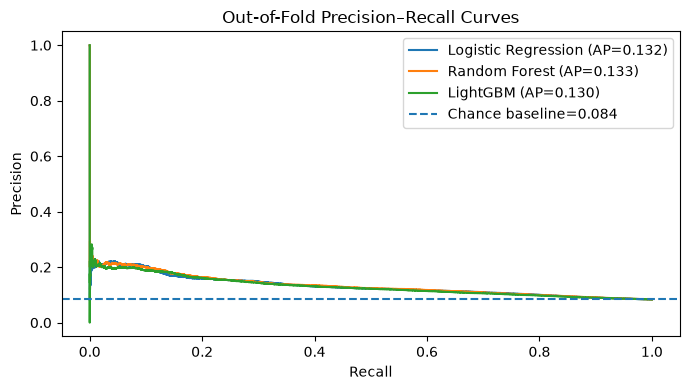

In [10]:
plt.figure(figsize=(7, 4))
for name, p in oof_store.items():
    mask = ~np.isnan(p)
    precision, recall, _ = precision_recall_curve(y.iloc[mask], p[mask])
    ap = average_precision_score(y.iloc[mask], p[mask])
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

chance = y.mean()
plt.axhline(chance, linestyle="--", label=f"Chance baseline={chance:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Out-of-Fold Precision–Recall Curves")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "pr_curves.png", dpi=150)
plt.show()


### Interpretation 
Under identical five-fold purged temporal validation, Random Forest achieved the highest mean PR-AUC (0.134 ± 0.006), narrowly ahead of Logistic Regression (0.133 ± 0.003) and LightGBM (0.132 ± 0.010). All models exceeded the empirical chance baseline of 0.084, indicating useful ranking ability under the imbalanced fraud distribution. However, the differences between Random Forest and Logistic Regression were small, while Logistic Regression showed the lowest fold-to-fold variability. Untuned LightGBM exhibited the greatest temporal variability, supporting further hyperparameter optimisation before final model selection.

## 5. Imbalance handling

Compare plain Logistic Regression, class-weighted Logistic Regression, and SMOTE-NC with resampling inside each training fold.


In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

weighted_logistic = Pipeline([
    ("prep", build_lr_preprocessor()),
    ("model", LogisticRegression(
        C=1.0, max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ))
])

smote_numeric = Pipeline([("impute", SimpleImputer(strategy="median"))])
smote_categorical = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])
smote_preprocessor = ColumnTransformer([
    ("num", smote_numeric, NUMERICAL_COLS),
    ("cat", smote_categorical, CATEGORY_COLS),
])

n_num = len(NUMERICAL_COLS)
cat_indices = list(range(n_num, n_num + len(CATEGORY_COLS)))

post_smote = ColumnTransformer([
    ("num", Pipeline([
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scale", RobustScaler()),
    ]), list(range(n_num))),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_indices),
])

smote_logistic = ImbPipeline([
    ("pre_smote", smote_preprocessor),
    ("smote", SMOTENC(categorical_features=cat_indices, sampling_strategy=0.30, random_state=RANDOM_STATE)),
    ("post_smote", post_smote),
    ("model", LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE))
])

imbalance_models = {
    "Plain LR": logistic_model,
    "Class-weighted LR": weighted_logistic,
    "SMOTE-NC LR": smote_logistic,
}


In [12]:
imbalance_fold_results = []
imbalance_oof = {}

for name, model in imbalance_models.items():
    result, oof = evaluate_model_cv(name, model, X, y, folds)
    imbalance_fold_results.append(result)
    imbalance_oof[name] = oof

imbalance_fold_results = pd.concat(imbalance_fold_results, ignore_index=True)

imbalance_comparison = (
    imbalance_fold_results.groupby("Model")
    .agg(
        PR_AUC_mean=("PR-AUC", "mean"),
        PR_AUC_std=("PR-AUC", "std"),
        ROC_AUC_mean=("ROC-AUC", "mean"),
        Brier_mean=("Brier", "mean"),
    )
    .sort_values("PR_AUC_mean", ascending=False)
    .reset_index()
)
imbalance_comparison


Plain LR               | fold 1 | PR-AUC=0.1255 | ROC-AUC=0.6148
Plain LR               | fold 2 | PR-AUC=0.1386 | ROC-AUC=0.6331
Plain LR               | fold 3 | PR-AUC=0.1344 | ROC-AUC=0.6226
Plain LR               | fold 4 | PR-AUC=0.1330 | ROC-AUC=0.6238
Plain LR               | fold 5 | PR-AUC=0.1344 | ROC-AUC=0.6249
Class-weighted LR      | fold 1 | PR-AUC=0.1249 | ROC-AUC=0.6145
Class-weighted LR      | fold 2 | PR-AUC=0.1384 | ROC-AUC=0.6328
Class-weighted LR      | fold 3 | PR-AUC=0.1339 | ROC-AUC=0.6231
Class-weighted LR      | fold 4 | PR-AUC=0.1326 | ROC-AUC=0.6235
Class-weighted LR      | fold 5 | PR-AUC=0.1338 | ROC-AUC=0.6249
SMOTE-NC LR            | fold 1 | PR-AUC=0.1159 | ROC-AUC=0.5979
SMOTE-NC LR            | fold 2 | PR-AUC=0.1204 | ROC-AUC=0.6151
SMOTE-NC LR            | fold 3 | PR-AUC=0.1179 | ROC-AUC=0.6045
SMOTE-NC LR            | fold 4 | PR-AUC=0.1182 | ROC-AUC=0.6007
SMOTE-NC LR            | fold 5 | PR-AUC=0.1172 | ROC-AUC=0.6022


,Model,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,Brier_mean
0,Plain LR,0.133209,0.004774,0.623825,0.075290
1,Class-weighted LR,0.132742,0.004901,0.623759,0.238654
2,SMOTE-NC LR,0.117944,0.001641,0.604095,0.096053


**Imbalance treatment** 

Two imbalance remedies were evaluated against the unweighted Logistic Regression baseline using the same purged temporal folds. Class weighting produced almost unchanged ranking performance (PR-AUC 0.133 versus 0.133 for the baseline) but substantially worsened the Brier score from 0.075 to 0.239, indicating distorted raw probability estimates. SMOTE-NC reduced mean PR-AUC to 0.118 and ROC-AUC to 0.604, with poorer results across all five folds. Consequently, neither approach was retained for the main modelling pipeline. The original class distribution was preserved, with asymmetric costs addressed later through threshold optimisation.

## 6. Controlled leakage demonstration: resampling before CV

This section is not used for model selection. It intentionally demonstrates the invalid practice of preprocessing/resampling the full dataset before cross-validation.


In [13]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_validate

demo_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# CORRECT: oversampling occurs only inside each training fold
proper_ros_pipeline = ImbPipeline([
    ("prep", build_lr_preprocessor()),
    ("ros", RandomOverSampler(sampling_strategy=0.30, random_state=RANDOM_STATE)),
    ("model", LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE))
])
proper_scores = cross_validate(
    proper_ros_pipeline, X, y, cv=demo_cv,
    scoring={"pr_auc": "average_precision","roc_auc": "roc_auc"}, 
    n_jobs=1
)

# WRONG: preprocessing and oversampling before cross-validation
wrong_preprocessor = build_lr_preprocessor()
X_all_transformed = wrong_preprocessor.fit_transform(X, y)
ros = RandomOverSampler(sampling_strategy=0.30, random_state=RANDOM_STATE)
X_resampled, y_resampled = ros.fit_resample(X_all_transformed, y)

wrong_scores = cross_validate(
    LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE),
    X_resampled, y_resampled, cv=demo_cv,
    scoring={"pr_auc": "average_precision","roc_auc": "roc_auc"}, 
    n_jobs=1
)

print(f"Correct inside-fold resampling PR-AUC: {proper_scores['test_pr_auc'].mean():.4f} +/- {proper_scores['test_pr_auc'].std():.4f}")
print(f"WRONG pre-CV resampling PR-AUC:       {wrong_scores['test_pr_auc'].mean():.4f} +/- {wrong_scores['test_pr_auc'].std():.4f}")
print(f"Correct inside-fold resampling ROC-AUC: {proper_scores['test_roc_auc'].mean():.4f} +/- {proper_scores['test_roc_auc'].std():.4f}")
print(f"WRONG pre-CV resampling ROC-AUC:       {wrong_scores['test_roc_auc'].mean():.4f} +/- {wrong_scores['test_roc_auc'].std():.4f}")
print("Original positive rate:", round(y.mean(), 4))
print("Wrong resampled positive rate:", round(pd.Series(y_resampled).mean(), 4))
print("The second score is deliberately invalid and must not be used for model selection.")


Correct inside-fold resampling PR-AUC: 0.1345 +/- 0.0033
WRONG pre-CV resampling PR-AUC:       0.3328 +/- 0.0034
Correct inside-fold resampling ROC-AUC: 0.6242 +/- 0.0078
WRONG pre-CV resampling ROC-AUC:       0.6257 +/- 0.0023
Original positive rate: 0.084
Wrong resampled positive rate: 0.2308
The second score is deliberately invalid and must not be used for model selection.


Resampling before cross-validation produced an apparently much higher PR-AUC (0.333 versus 0.135), but this was largely caused by contaminating the evaluation protocol and changing the validation prevalence from 8.4% to 23.1%. ROC-AUC remained almost unchanged (0.624 versus 0.626), confirming that the apparent PR-AUC improvement did not represent a comparable improvement in ranking ability. Evaluation must therefore be performed on the original, untouched class distribution, with resampling restricted to the training portion of each fold.

## 7. Optuna: budget-limited LightGBM tuning

Budget: 60 trials. Objective: mean PR-AUC over the same five purged folds. The study uses TPE sampling, a MedianPruner, and SQLite persistence in `a2_optuna_study.db`.


In [14]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEARCH_SPACE_DESCRIPTION = {
    "learning_rate": "0.01 to 0.20, log scale",
    "num_leaves": "15 to 127",
    "max_depth": "3 to 10",
    "min_child_samples": "20 to 300, log scale",
    "subsample": "0.60 to 1.00",
    "colsample_bytree": "0.60 to 1.00",
    "reg_alpha": "1e-4 to 10, log scale",
    "reg_lambda": "1e-3 to 50, log scale",
}
SEARCH_SPACE_DESCRIPTION


{'learning_rate': '0.01 to 0.20, log scale',
 'num_leaves': '15 to 127',
 'max_depth': '3 to 10',
 'min_child_samples': '20 to 300, log scale',
 'subsample': '0.60 to 1.00',
 'colsample_bytree': '0.60 to 1.00',
 'reg_alpha': '1e-4 to 10, log scale',
 'reg_lambda': '1e-3 to 50, log scale'}

In [15]:
def optuna_objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 300, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),
    }

    fold_scores = []
    for fold_no, (train_idx, val_idx) in enumerate(folds):
        model = Pipeline([
            ("prep", build_tree_preprocessor()),
            ("model", LGBMClassifier(
                n_estimators=350, subsample_freq=1,
                random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1,
                **params
            ))
        ])
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        p = model.predict_proba(X.iloc[val_idx])[:, 1]
        score = average_precision_score(y.iloc[val_idx], p)
        fold_scores.append(score)

        trial.report(float(np.mean(fold_scores)), step=fold_no)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


In [16]:
storage_path = f"sqlite:///{DB_DIR / '053837_a2_optuna_study.db'}"

try:
    optuna.delete_study(study_name="a2_lightgbm_purged_cv", storage=storage_path)
    print("Existing study deleted — starting fresh.")
except KeyError:
    print("No existing study found — nothing to delete.")

Existing study deleted — starting fresh.


In [17]:
study = optuna.create_study(
    study_name="a2_lightgbm_purged_cv",
    direction="maximize",
    storage=storage_path,
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)
)

study.optimize(optuna_objective, n_trials=60, gc_after_trial=True)

print("Best trial:", study.best_trial.number)
print("Best mean purged-CV PR-AUC:", round(study.best_value, 4))
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


Best trial: 5
Best mean purged-CV PR-AUC: 0.1406
Best parameters:
  learning_rate: 0.014413697528610409
  num_leaves: 70
  max_depth: 3
  min_child_samples: 234
  subsample: 0.7035119926400067
  colsample_bytree: 0.8650089137415928
  reg_alpha: 0.003618723330959626
  reg_lambda: 0.2778331300797557


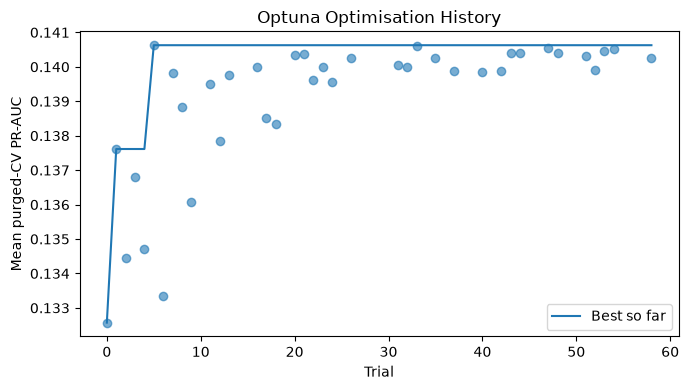

Completed trials: 38
Pruned trials: 22


In [18]:
trials_df = study.trials_dataframe()
completed = trials_df[trials_df["state"] == "COMPLETE"].copy()

plt.figure(figsize=(7, 4))
plt.scatter(completed["number"], completed["value"], alpha=0.6)
plt.plot(completed["number"], completed["value"].cummax(), label="Best so far")
plt.xlabel("Trial")
plt.ylabel("Mean purged-CV PR-AUC")
plt.title("Optuna Optimisation History")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "a2_optuna_history.png", dpi=300, bbox_inches="tight")
plt.show()


print("Completed trials:", len(completed))
print("Pruned trials:", int((trials_df["state"] == "PRUNED").sum()))


## 8. Re-evaluate tuned LightGBM on the exact same five purged folds


In [19]:
tuned_lightgbm = Pipeline([
    ("prep", build_tree_preprocessor()),
    ("model", LGBMClassifier(
        n_estimators=350, subsample_freq=1,
        random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1,
        **study.best_params
    ))
])

tuned_fold_results, tuned_oof = evaluate_model_cv(
    "LightGBM Tuned", tuned_lightgbm, X, y, folds
)
oof_store["LightGBM Tuned"] = tuned_oof

all_fold_results = pd.concat([base_fold_results, tuned_fold_results], ignore_index=True)
model_comparison = (
    all_fold_results.groupby("Model")
    .agg(
        PR_AUC_mean=("PR-AUC", "mean"),
        PR_AUC_std=("PR-AUC", "std"),
        ROC_AUC_mean=("ROC-AUC", "mean"),
        ROC_AUC_std=("ROC-AUC", "std"),
        Brier_mean=("Brier", "mean"),
    )
    .sort_values("PR_AUC_mean", ascending=False)
    .reset_index()
)
model_comparison


LightGBM Tuned         | fold 1 | PR-AUC=0.1352 | ROC-AUC=0.6244
LightGBM Tuned         | fold 2 | PR-AUC=0.1438 | ROC-AUC=0.6391
LightGBM Tuned         | fold 3 | PR-AUC=0.1416 | ROC-AUC=0.6312
LightGBM Tuned         | fold 4 | PR-AUC=0.1430 | ROC-AUC=0.6366
LightGBM Tuned         | fold 5 | PR-AUC=0.1395 | ROC-AUC=0.6324


,Model,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,ROC_AUC_std,Brier_mean
0,LightGBM Tuned,0.140627,0.003419,0.632747,0.005638,0.074968
1,Random Forest,0.134006,0.003919,0.624928,0.005492,0.075245
2,Logistic Regression,0.133209,0.004774,0.623825,0.006529,0.075290
3,LightGBM,0.131713,0.006590,0.617910,0.009259,0.075652


In [20]:
print(model_comparison[[
    "Model", "PR_AUC_mean", "PR_AUC_std", "ROC_AUC_mean", "ROC_AUC_std"
]].to_string(index=False))

print("Use fold dispersion as an empirical stability diagnostic. Random Forest primarily reduces tree variance; boosting sequentially reduces residual bias and then variance.")


              Model  PR_AUC_mean  PR_AUC_std  ROC_AUC_mean  ROC_AUC_std
     LightGBM Tuned     0.140627    0.003419      0.632747     0.005638
      Random Forest     0.134006    0.003919      0.624928     0.005492
Logistic Regression     0.133209    0.004774      0.623825     0.006529
           LightGBM     0.131713    0.006590      0.617910     0.009259
Use fold dispersion as an empirical stability diagnostic. Random Forest primarily reduces tree variance; boosting sequentially reduces residual bias and then variance.


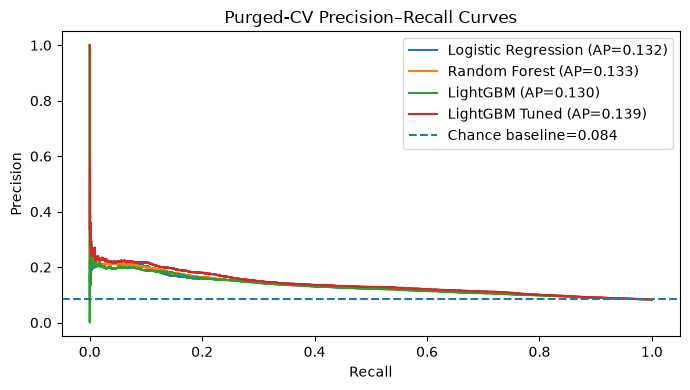

In [60]:
plt.figure(figsize=(7, 4))

for name, p in oof_store.items():
    mask = ~np.isnan(p)

    precision, recall, _ = precision_recall_curve(
        y.iloc[mask],
        p[mask]
    )

    ap = average_precision_score(
        y.iloc[mask],
        p[mask]
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})"
    )

plt.axhline(
    y.mean(),
    linestyle="--",
    label=f"Chance baseline={y.mean():.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Purged-CV Precision–Recall Curves")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "final_pr_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Select the champion by mean PR-AUC


In [22]:
candidate_estimators = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "LightGBM": lightgbm_model,
    "LightGBM Tuned": tuned_lightgbm,
}

champion_name = model_comparison.iloc[0]["Model"]
champion_estimator = candidate_estimators[champion_name]
champion_oof = oof_store[champion_name]
print("Champion by mean PR-AUC:", champion_name)


Champion by mean PR-AUC: LightGBM Tuned


## 10. Probability calibration

Use only honest out-of-fold predictions. Split them chronologically: first 60% to fit candidate calibrators, next 20% to choose Platt versus isotonic by Brier score, and final 20% as an untouched decision-evaluation window.


In [39]:
from sklearn.isotonic import IsotonicRegression

valid_oof_idx = np.where(~np.isnan(champion_oof))[0]
valid_oof_idx = valid_oof_idx[np.argsort(df_dev.loc[valid_oof_idx, TIME_COL].values)]

n_oof = len(valid_oof_idx)
cut_60 = int(0.60 * n_oof)
cut_80 = int(0.80 * n_oof)

idx_cal_fit = valid_oof_idx[:cut_60]
idx_cal_select = valid_oof_idx[cut_60:cut_80]
idx_decision = valid_oof_idx[cut_80:]

print("Calibration fit:", len(idx_cal_fit))
print("Calibration selection:", len(idx_cal_select))
print("Decision evaluation:", len(idx_decision))
print("Decision window:", df_dev.loc[idx_decision[0], TIME_COL], "to", df_dev.loc[idx_decision[-1], TIME_COL])


Calibration fit: 75349
Calibration selection: 25117
Decision evaluation: 25117
Decision window: 2026-02-19 00:46:00 to 2026-05-04 07:16:17


In [40]:
def probability_to_logit(p):
    p = np.clip(np.asarray(p), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def fit_calibrator(kind, p, y_true):
    p = np.asarray(p)
    y_true = np.asarray(y_true)

    if kind == "platt":
        model = LogisticRegression(C=1e6, max_iter=2000, random_state=RANDOM_STATE)
        model.fit(probability_to_logit(p).reshape(-1, 1), y_true)
        return model

    if kind == "isotonic":
        model = IsotonicRegression(out_of_bounds="clip")
        model.fit(p, y_true)
        return model

    raise ValueError("Unknown calibrator")


def apply_calibrator(model, kind, p):
    p = np.asarray(p)
    if kind == "platt":
        return model.predict_proba(probability_to_logit(p).reshape(-1, 1))[:, 1]
    if kind == "isotonic":
        return model.predict(p)
    raise ValueError("Unknown calibrator")


In [41]:
calibration_selection_rows = []

for kind in ["platt", "isotonic"]:
    calibrator = fit_calibrator(kind, champion_oof[idx_cal_fit], y.iloc[idx_cal_fit])
    p_selected = apply_calibrator(calibrator, kind, champion_oof[idx_cal_select])

    calibration_selection_rows.append({
        "Method": kind,
        "Brier": brier_score_loss(y.iloc[idx_cal_select], p_selected),
        "PR-AUC": average_precision_score(y.iloc[idx_cal_select], p_selected),
    })

calibration_selection = pd.DataFrame(calibration_selection_rows).sort_values("Brier")
calibration_selection


,Method,Brier,PR-AUC
0,platt,0.075728,0.142965
1,isotonic,0.075766,0.135416


In [42]:
best_calibration_method = calibration_selection.iloc[0]["Method"]
idx_calibration_full = valid_oof_idx[:cut_80]

selected_calibrator = fit_calibrator(
    best_calibration_method,
    champion_oof[idx_calibration_full],
    y.iloc[idx_calibration_full]
)

p_raw_decision = champion_oof[idx_decision]
p_cal_decision = apply_calibrator(
    selected_calibrator,
    best_calibration_method,
    p_raw_decision
)

print("Selected calibration method:", best_calibration_method)
print("Raw Brier:", round(brier_score_loss(y.iloc[idx_decision], p_raw_decision), 5))
print("Calibrated Brier:", round(brier_score_loss(y.iloc[idx_decision], p_cal_decision), 5))


Selected calibration method: platt
Raw Brier: 0.07437
Calibrated Brier: 0.07436


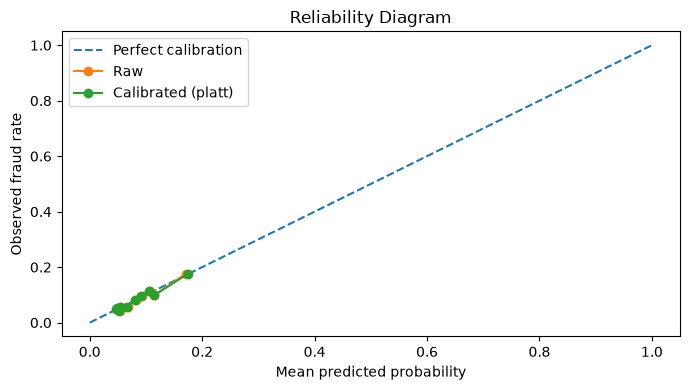

In [59]:
raw_frac, raw_mean = calibration_curve(
    y.iloc[idx_decision], p_raw_decision, n_bins=10, strategy="quantile"
)
cal_frac, cal_mean = calibration_curve(
    y.iloc[idx_decision], p_cal_decision, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 4))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(raw_mean, raw_frac, marker="o", label="Raw")
plt.plot(cal_mean, cal_frac, marker="o", label=f"Calibrated ({best_calibration_method})")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraud rate")
plt.title("Reliability Diagram")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "reliability_diagram.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Cost-based threshold selection


In [44]:
def cost_at_threshold(y_true, p, threshold, cost_fn=COST_FN, cost_fp=COST_FP):
    pred = (np.asarray(p) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    total_cost = cost_fn * fn + cost_fp * fp
    return {
        "threshold": threshold,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "total_cost": total_cost,
        "cost_per_1000": total_cost / len(y_true) * 1000,
    }


def exact_minimum_cost_threshold(y_true, p, cost_fn=COST_FN, cost_fp=COST_FP):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)

    order = np.argsort(-p)
    p_sorted = p[order]
    y_sorted = y_true[order]
    positives = y_sorted.sum()

    tp = np.cumsum(y_sorted)
    fp = np.arange(1, len(y_sorted) + 1) - tp
    fn = positives - tp
    costs_after_k = cost_fn * fn + cost_fp * fp

    cost_none = cost_fn * positives
    all_costs = np.concatenate([[cost_none], costs_after_k])
    best_k = int(np.argmin(all_costs))
    best_cost = float(all_costs[best_k])

    threshold = 1.0 + 1e-12 if best_k == 0 else float(p_sorted[best_k - 1])
    return threshold, best_cost


In [45]:
y_decision = y.iloc[idx_decision].to_numpy()

raw_best_threshold, raw_best_cost = exact_minimum_cost_threshold(y_decision, p_raw_decision)
cal_best_threshold, cal_best_cost = exact_minimum_cost_threshold(y_decision, p_cal_decision)

print(f"Raw empirical best threshold:        {raw_best_threshold:.4f}")
print(f"Calibrated empirical best threshold: {cal_best_threshold:.4f}")
print(f"Theoretical calibrated threshold:    {THEORETICAL_COST_THRESHOLD:.4f}")
print("Calibration threshold movement:", round(cal_best_threshold - raw_best_threshold, 4))


Raw empirical best threshold:        0.0800
Calibrated empirical best threshold: 0.0784
Theoretical calibrated threshold:    0.0741
Calibration threshold movement: -0.0016


In [46]:
cost_empirical = cost_at_threshold(y_decision, p_cal_decision, cal_best_threshold)
cost_theoretical = cost_at_threshold(y_decision, p_cal_decision, THEORETICAL_COST_THRESHOLD)
cost_050 = cost_at_threshold(y_decision, p_cal_decision, 0.50)

savings_per_1000 = cost_050["cost_per_1000"] - cost_empirical["cost_per_1000"]

cost_table = pd.DataFrame([
    {"Rule": "Empirical minimum-cost", **cost_empirical},
    {"Rule": "Theoretical calibrated cost threshold", **cost_theoretical},
    {"Rule": "Naive 0.50", **cost_050},
])
cost_table


,Rule,threshold,tn,fp,fn,tp,total_cost,cost_per_1000
0,Empirical minimum-cost,0.078390,12422,10614,687,1394,15361200,611585.778556
1,Theoretical calibrated cost threshold,0.074074,11196,11840,599,1482,15462000,615598.996695
2,Naive 0.50,0.500000,23036,0,2081,0,20810000,828522.514632


In [47]:
print(f"Saving from cost-based threshold versus 0.50: KES {savings_per_1000:,.0f} per 1,000 transactions")
print(f"Confusion matrix at threshold {cal_best_threshold:.4f}:")
print(np.array([
    [cost_empirical["tn"], cost_empirical["fp"]],
    [cost_empirical["fn"], cost_empirical["tp"]]
]))


Saving from cost-based threshold versus 0.50: KES 216,937 per 1,000 transactions
Confusion matrix at threshold 0.0784:
[[12422 10614]
 [  687  1394]]


## 12. Fairness / subgroup diagnostics

For this fraud dataset, the assignment's approval rate is interpreted as the **not-flagged rate**: the share of transactions allowed through. Report the not-flagged rate and false-negative rate by `region` and `segment`.


In [48]:
decision_prediction = (p_cal_decision >= cal_best_threshold).astype(int)

decision_frame = df_dev.loc[idx_decision, ["region", "segment", TARGET]].copy()
decision_frame["prediction"] = decision_prediction


def subgroup_metrics(frame, group_col):
    rows = []
    for group, g in frame.groupby(group_col, dropna=False):
        actual = g[TARGET].to_numpy()
        pred = g["prediction"].to_numpy()
        tn, fp, fn, tp = confusion_matrix(actual, pred, labels=[0, 1]).ravel()

        approval_rate = np.mean(pred == 0)
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        rows.append({
            group_col: group,
            "n": len(g),
            "actual_fraud_cases": int(actual.sum()),
            "approval_not_flagged_rate": approval_rate,
            "false_negative_rate": fnr,
            "false_positives": int(fp),
            "false_negatives": int(fn),
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)

fairness_region = subgroup_metrics(decision_frame, "region")
fairness_segment = subgroup_metrics(decision_frame, "segment")

print("REGION")
display(fairness_region)
print("SEGMENT")
display(fairness_segment)


REGION


,region,n,actual_fraud_cases,approval_not_flagged_rate,false_negative_rate,false_positives,false_negatives
0,Mombasa,2762,249,0.482621,0.305221,1256,76
1,Jinja,2713,235,0.544784,0.361702,1085,85
2,Kigali,2680,197,0.516418,0.350254,1168,69
3,Nairobi,2610,233,0.503065,0.334764,1142,78
4,Mwanza,2467,195,0.518443,0.384615,1068,75
5,Arusha,2427,197,0.553358,0.350254,956,69
6,Dar es Salaam,2402,202,0.521649,0.292079,1006,59
7,Eldoret,2395,200,0.515658,0.280000,1016,56
8,Kampala,2345,201,0.522388,0.308458,981,62
9,Nakuru,2316,172,0.546632,0.337209,936,58


SEGMENT


,segment,n,actual_fraud_cases,approval_not_flagged_rate,false_negative_rate,false_positives,false_negatives
0,retail,20173,1654,0.517176,0.324063,8622,536
1,merchant,3661,309,0.529637,0.359223,1524,111
2,agent,1283,118,0.574435,0.338983,468,40


## 13. Fit the final champion and generate SHAP explanations

Global explanation: SHAP beeswarm. Local explanation: SHAP waterfall for one transaction.


In [49]:
import shap
import joblib

final_model = clone(champion_estimator)
final_model.fit(X, y)

prep = final_model.named_steps["prep"]
model_core = final_model.named_steps["model"]

rng = np.random.default_rng(RANDOM_STATE)
background_idx = rng.choice(len(X), size=min(300, len(X)), replace=False)
explain_idx = rng.choice(len(X), size=min(1000, len(X)), replace=False)

feature_names = prep.get_feature_names_out()
X_background_t = prep.transform(X.iloc[background_idx])
X_explain_t = prep.transform(X.iloc[explain_idx])

if hasattr(X_background_t, "toarray"):
    X_background_t = X_background_t.toarray()
if hasattr(X_explain_t, "toarray"):
    X_explain_t = X_explain_t.toarray()

X_background_df = pd.DataFrame(X_background_t, columns=feature_names)
X_explain_df = pd.DataFrame(X_explain_t, columns=feature_names)

if isinstance(model_core, LogisticRegression):
    explainer = shap.LinearExplainer(model_core, X_background_df)
    shap_values = explainer(X_explain_df)
else:
    explainer = shap.TreeExplainer(model_core)
    shap_values = explainer(X_explain_df)

if getattr(shap_values.values, "ndim", 2) == 3:
    shap_values = shap_values[:, :, 1]

print("SHAP values shape:", shap_values.values.shape)


SHAP values shape: (1000, 35)


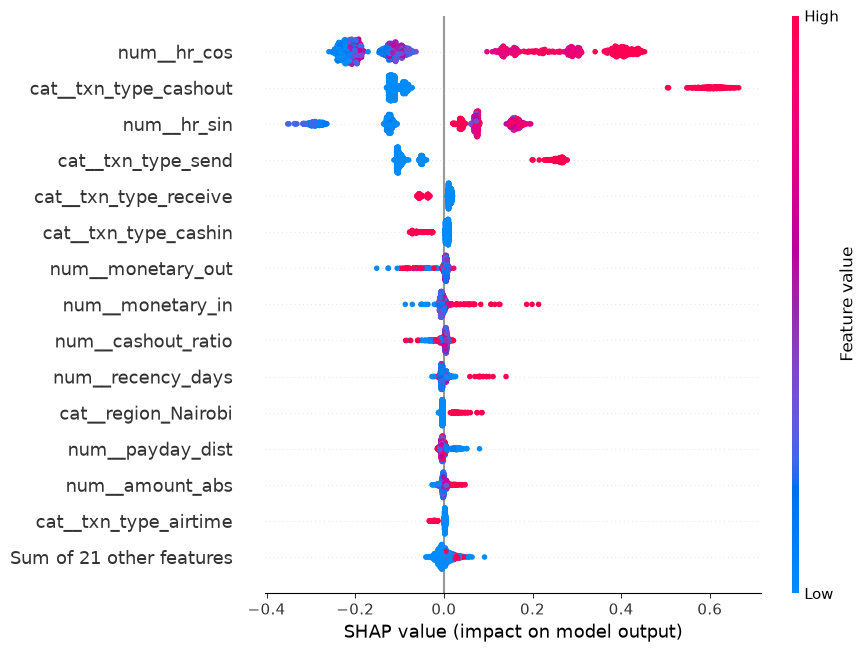

In [62]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)

# Save the figure
fig = plt.gcf()

fig.savefig(FIG_DIR / "shap_global_summary.png",dpi=300,bbox_inches="tight")

plt.show()


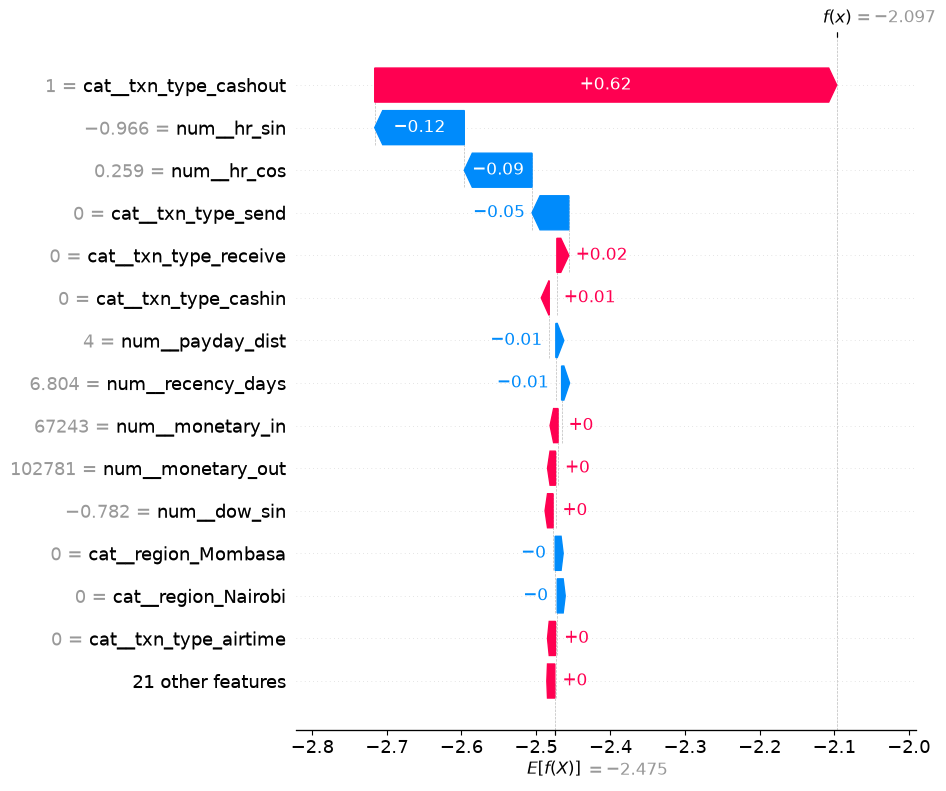

In [63]:
# Local SHAP waterfall explanation
shap.plots.waterfall(shap_values[0],max_display=15,show=False)

# Save the current SHAP figure
fig = plt.gcf()

fig.savefig(FIG_DIR / "shap_waterfall.png",dpi=300,bbox_inches="tight")

plt.show()


## 14. Final calibration object for deployment

After evaluation is complete, refit the selected calibration method using all available honest OOF predictions. Save this separately from the fitted classifier.


In [52]:
final_calibrator = fit_calibrator(
    best_calibration_method,
    champion_oof[valid_oof_idx],
    y.iloc[valid_oof_idx]
)

print("Final model:", champion_name)
print("Calibration:", best_calibration_method)
print("Recommended deployment threshold:", round(cal_best_threshold, 4))
print("Savings vs 0.50:", f"KES {savings_per_1000:,.0f} per 1,000 transactions")


Final model: LightGBM Tuned
Calibration: platt
Recommended deployment threshold: 0.0784
Savings vs 0.50: KES 216,937 per 1,000 transactions


## 15. Final Untouched Out-of-Time Holdout Evaluation

The final model, calibration method and operating threshold were selected
using development data only.

The out-of-time holdout has remained completely untouched during:

- model comparison,
- imbalance treatment,
- hyperparameter optimisation,
- calibration selection,
- threshold optimisation,
- fairness analysis, and
- explainability analysis.

It is now used once to estimate final generalisation performance.

In [53]:

#  Confirm the final model has been fitted on ALL dev data


print("Final model:", champion_name)
print("Calibration method:", best_calibration_method)
print(f"Fixed deployment threshold: {cal_best_threshold:.4f}")

print(
    "\nDevelopment period:",
    ts.min(),
    "to",
    ts.max()
)

print(
    "Holdout period:",
    ts_test.min(),
    "to",
    ts_test.max()
)

print(
    f"\nDevelopment rows: {len(X):,}"
)

print(
    f"Holdout rows: {len(X_test):,}"
)

Final model: LightGBM Tuned
Calibration method: platt
Fixed deployment threshold: 0.0784

Development period: 2025-02-06 00:46:00 to 2026-05-04 07:16:17
Holdout period: 2026-05-11 07:21:00 to 2026-07-31 22:11:42

Development rows: 150,700
Holdout rows: 27,000


In [54]:

# Generate raw probabilities on the untouched holdout

p_test_raw = final_model.predict_proba(
    X_test
)[:, 1]



# Apply the calibration model fitted on DEV OOF predictions


p_test_cal = apply_calibrator(
    final_calibrator,
    best_calibration_method,
    p_test_raw
)


# Final ranking and calibration metrics


holdout_pr_auc = average_precision_score(
    y_test,
    p_test_cal
)

holdout_roc_auc = roc_auc_score(
    y_test,
    p_test_cal
)

holdout_brier = brier_score_loss(
    y_test,
    p_test_cal
)

print("=" * 65)
print("FINAL OUT-OF-TIME HOLDOUT PERFORMANCE")
print("=" * 65)

print(
    f"Fraud prevalence: {y_test.mean():.2%}"
)

print(
    f"PR-AUC:           {holdout_pr_auc:.4f}"
)

print(
    f"ROC-AUC:          {holdout_roc_auc:.4f}"
)

print(
    f"Brier score:      {holdout_brier:.5f}"
)

FINAL OUT-OF-TIME HOLDOUT PERFORMANCE
Fraud prevalence: 8.44%
PR-AUC:           0.1431
ROC-AUC:          0.6408
Brier score:      0.07558


In [55]:
# Raw versus calibrated holdout performance

holdout_pr_auc_raw = average_precision_score(
    y_test,
    p_test_raw
)

holdout_roc_auc_raw = roc_auc_score(
    y_test,
    p_test_raw
)

holdout_brier_raw = brier_score_loss(
    y_test,
    p_test_raw
)

holdout_metric_table = pd.DataFrame([
    {
        "Probability": "Raw",
        "PR-AUC": holdout_pr_auc_raw,
        "ROC-AUC": holdout_roc_auc_raw,
        "Brier": holdout_brier_raw
    },
    {
        "Probability": f"Calibrated ({best_calibration_method})",
        "PR-AUC": holdout_pr_auc,
        "ROC-AUC": holdout_roc_auc,
        "Brier": holdout_brier
    }
])

holdout_metric_table

,Probability,PR-AUC,ROC-AUC,Brier
0,Raw,0.143075,0.64084,0.075585
1,Calibrated (platt),0.143075,0.64084,0.075580


In [56]:

# FINAL BUSINESS-COST EVALUATION


# Threshold was selected using DEVELOPMENT data.
# It is NOT re-optimised on the holdout.

DEPLOYMENT_THRESHOLD = cal_best_threshold

holdout_cost = cost_at_threshold(
    y_test,
    p_test_cal,
    DEPLOYMENT_THRESHOLD
)

holdout_cost_050 = cost_at_threshold(
    y_test,
    p_test_cal,
    0.50
)

holdout_cost_theoretical = cost_at_threshold(
    y_test,
    p_test_cal,
    THEORETICAL_COST_THRESHOLD
)

holdout_savings_per_1000 = (
    holdout_cost_050["cost_per_1000"]
    - holdout_cost["cost_per_1000"]
)

holdout_cost_table = pd.DataFrame([
    {
        "Rule": "Selected development threshold",
        **holdout_cost
    },
    {
        "Rule": "Theoretical calibrated threshold",
        **holdout_cost_theoretical
    },
    {
        "Rule": "Naive 0.50",
        **holdout_cost_050
    }
])

holdout_cost_table

,Rule,threshold,tn,fp,fn,tp,total_cost,cost_per_1000
0,Selected development threshold,0.078390,13461,11259,746,1534,16467200,609896.296296
1,Theoretical calibrated threshold,0.074074,12170,12550,650,1630,16540000,612592.592593
2,Naive 0.50,0.500000,24720,0,2280,0,22800000,844444.444444


In [57]:
print(
    f"Fixed deployment threshold: "
    f"{DEPLOYMENT_THRESHOLD:.4f}"
)

print(
    f"\nCost at selected threshold: "
    f"KES {holdout_cost['cost_per_1000']:,.0f} per 1,000"
)

print(
    f"Cost at 0.50 threshold:     "
    f"KES {holdout_cost_050['cost_per_1000']:,.0f} per 1,000"
)

print(
    f"Savings versus 0.50:        "
    f"KES {holdout_savings_per_1000:,.0f} per 1,000"
)

print("\nFinal holdout confusion matrix:")

print(
    np.array([
        [holdout_cost["tn"], holdout_cost["fp"]],
        [holdout_cost["fn"], holdout_cost["tp"]]
    ])
)

Fixed deployment threshold: 0.0784

Cost at selected threshold: KES 609,896 per 1,000
Cost at 0.50 threshold:     KES 844,444 per 1,000
Savings versus 0.50:        KES 234,548 per 1,000

Final holdout confusion matrix:
[[13461 11259]
 [  746  1534]]


## 15. Save all Assignment 2 outputs


In [58]:
A2_DATA_DIR = PROJECT_ROOT/"a2_data"
A2_MODEL_DIR = PROJECT_ROOT/"a2_models"

import joblib


# Save model comparison and experiment tables


model_comparison.to_csv(A2_DATA_DIR/"model_comparison.csv",index=False)

base_fold_results.to_csv(A2_DATA_DIR/"base_model_fold_results.csv",index=False)

imbalance_comparison.to_csv(A2_DATA_DIR/"imbalance_comparison.csv",index=False)

calibration_selection.to_csv(A2_DATA_DIR/"calibration_comparison.csv",index=False)

cost_table.to_csv(A2_DATA_DIR/"development_cost_threshold_comparison.csv",index=False)

fairness_region.to_csv(A2_DATA_DIR/"fairness_by_region.csv",index=False)

fairness_segment.to_csv(A2_DATA_DIR/"fairness_by_segment.csv",index=False)

fold_summary.to_csv(A2_DATA_DIR/"purged_cv_fold_summary.csv",index=False)



# Save development OOF predictions

oof_output = pd.DataFrame({
    "ts": df_dev[TIME_COL].reset_index(drop=True),
    "y_true": y.reset_index(drop=True)
})

for name, p in oof_store.items():

    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    oof_output[f"p_{safe_name}"] = p

oof_output.to_csv(A2_DATA_DIR/"development_oof_predictions.csv",index=False)


# Save FINAL untouched holdout results


holdout_output = pd.DataFrame({
    "ts": ts_test.reset_index(drop=True),
    "y_true": y_test.reset_index(drop=True),
    "p_raw": p_test_raw,
    "p_calibrated": p_test_cal,
    "prediction": (
        p_test_cal >= DEPLOYMENT_THRESHOLD
    ).astype(int)
})

holdout_output.to_csv(A2_DATA_DIR/"final_holdout_predictions.csv",index=False)

holdout_metric_table.to_csv(A2_DATA_DIR/"final_holdout_metrics.csv",index=False
)

holdout_cost_table.to_csv(A2_DATA_DIR/"final_holdout_cost_comparison.csv",index=False)



# Save fitted champion model


joblib.dump(final_model,A2_MODEL_DIR/"final_model.joblib")



# Save calibration + business decision rule

joblib.dump(
    {
        "model_name": champion_name,
        "calibration_method": best_calibration_method,
        "calibrator": final_calibrator,
        "deployment_threshold": DEPLOYMENT_THRESHOLD,
        "cost_fn": COST_FN,
        "cost_fp": COST_FP,
        "feature_cols": FEATURE_COLS,
    },
    A2_MODEL_DIR/"calibration_and_threshold.joblib"
)



# Save final recommendation


recommendation = (
    f"Deploy {champion_name} with "
    f"{best_calibration_method} calibration "
    f"and a fraud-flag threshold of "
    f"{DEPLOYMENT_THRESHOLD:.4f}. "
    f"On the untouched out-of-time holdout, "
    f"the model achieved PR-AUC {holdout_pr_auc:.3f}, "
    f"ROC-AUC {holdout_roc_auc:.3f}, "
    f"and Brier score {holdout_brier:.4f}. "
    f"The selected threshold reduced estimated cost by "
    f"KES {holdout_savings_per_1000:,.0f} per 1,000 transactions "
    f"relative to the conventional 0.50 threshold."
)

with open(
    A2_DATA_DIR/"final_recommendation.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(recommendation)


# Confirmation

print("=" * 65)
print("ASSIGNMENT 2 OUTPUTS SAVED SUCCESSFULLY")
print("=" * 65)

print("\nFinal model:", champion_name)
print("Calibration:", best_calibration_method)
print(f"Deployment threshold: {DEPLOYMENT_THRESHOLD:.4f}")
print(f"Holdout PR-AUC: {holdout_pr_auc:.4f}")
print(f"Holdout ROC-AUC: {holdout_roc_auc:.4f}")
print(
    f"Savings vs 0.50: "
    f"KES {holdout_savings_per_1000:,.0f} per 1,000"
)

print("\nOptuna database already stored as: 053837_a2_optuna_study.db")

ASSIGNMENT 2 OUTPUTS SAVED SUCCESSFULLY

Final model: LightGBM Tuned
Calibration: platt
Deployment threshold: 0.0784
Holdout PR-AUC: 0.1431
Holdout ROC-AUC: 0.6408
Savings vs 0.50: KES 234,548 per 1,000

Optuna database already stored as: 053837_a2_optuna_study.db
